In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [3]:
# ── Generate synthetic data in D dimensions ──
np.random.seed(42)

D = 5       # Original high-dimensional space
N = 300     # Number of data points
M = 2       # Target lower-dimensional space (M < D)

# Create data that has most variance along 2 hidden directions
# so PCA should recover a meaningful 2D projection.
hidden = np.random.randn(N, 2)
W_true = np.random.randn(2, D)          # 2 latent directions → D dims
noise  = 0.3 * np.random.randn(N, D)    # small isotropic noise
X = hidden @ W_true + noise              # (N, D)

print(f"Data shape : {X.shape}  (N={N}, D={D})")
print(f"Target dims: M={M}")

Data shape : (300, 5)  (N=300, D=5)
Target dims: M=2


In [4]:
# ── PCA from scratch (eigen-decomposition) ──

# Step 1: Centre the data  (subtract the mean)
mean = X.mean(axis=0)          # (D,)
X_centered = X - mean          # (N, D)

# Step 2: Compute the covariance matrix  S = (1/N) Xᵀ X
S = (X_centered.T @ X_centered) / N   # (D, D)

# Step 3: Eigen-decomposition of S
eigenvalues, eigenvectors = np.linalg.eigh(S)

# eigh returns in ascending order → reverse to get largest first
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]    # columns are eigenvectors

print("Eigenvalues (sorted):")
for i, ev in enumerate(eigenvalues):
    print(f"  λ_{i+1} = {ev:.4f}")

# Step 4: Select the top-M eigenvectors  → projection matrix U_M
U_M = eigenvectors[:, :M]             # (D, M)

# Step 5: Project data onto M-dimensional subspace
Z = X_centered @ U_M                  # (N, M)

print(f"\nProjection matrix U_M shape : {U_M.shape}")
print(f"Projected data Z shape      : {Z.shape}")

Eigenvalues (sorted):
  λ_1 = 10.4037
  λ_2 = 3.9325
  λ_3 = 0.1025
  λ_4 = 0.0853
  λ_5 = 0.0796

Projection matrix U_M shape : (5, 2)
Projected data Z shape      : (300, 2)


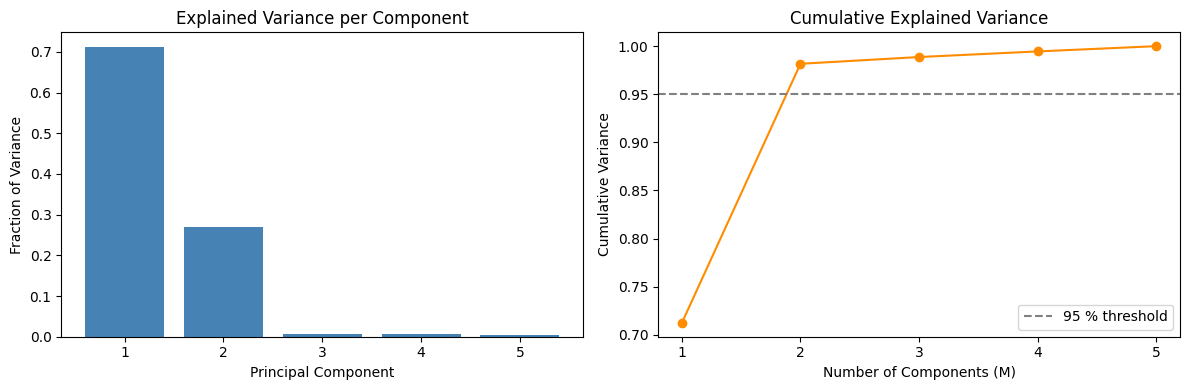


Top 2 components capture 98.2 % of total variance.


In [5]:
# ── Variance explained ──
total_var = eigenvalues.sum()
explained_ratio = eigenvalues / total_var

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart of individual explained variance
axes[0].bar(range(1, D + 1), explained_ratio, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Fraction of Variance")
axes[0].set_title("Explained Variance per Component")
axes[0].set_xticks(range(1, D + 1))

# Cumulative explained variance
cumulative = np.cumsum(explained_ratio)
axes[1].plot(range(1, D + 1), cumulative, "o-", color="darkorange")
axes[1].axhline(0.95, ls="--", color="gray", label="95 % threshold")
axes[1].set_xlabel("Number of Components (M)")
axes[1].set_ylabel("Cumulative Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xticks(range(1, D + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nTop {M} components capture {cumulative[M-1]*100:.1f} % of total variance.")

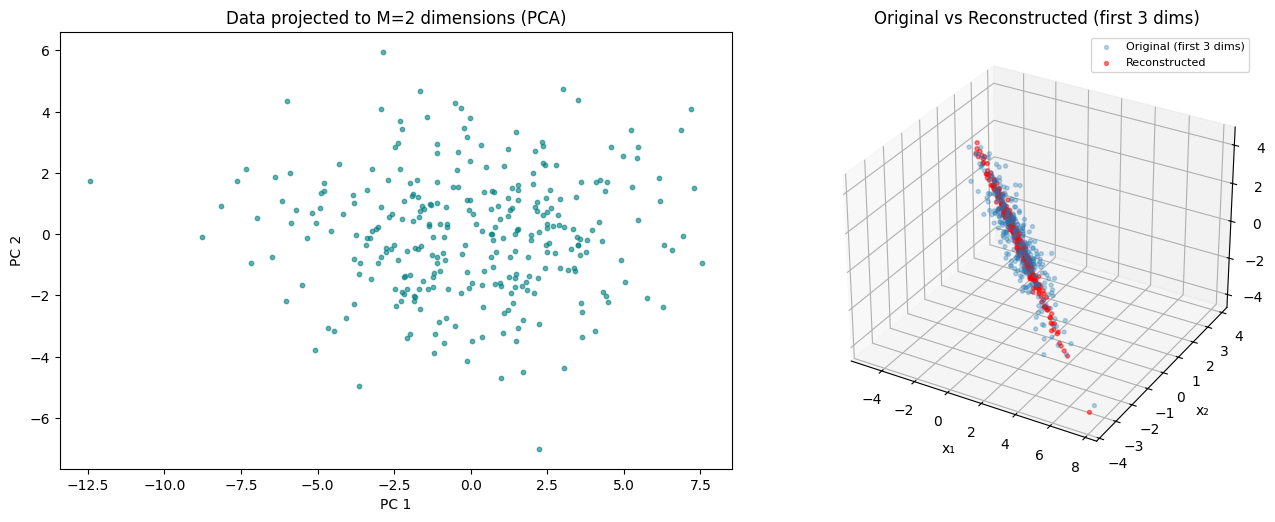

In [6]:
# ── Visualise the M=2 projection ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: 2-D scatter of the projected data
axes[0].scatter(Z[:, 0], Z[:, 1], s=10, alpha=0.6, c="teal")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")
axes[0].set_title(f"Data projected to M={M} dimensions (PCA)")
axes[0].set_aspect("equal")

# Right: first 3 original dims with projected points back in D-space
X_reconstructed = Z @ U_M.T + mean   # reconstruct back to D dims

ax3d = fig.add_subplot(122, projection="3d")
ax3d.scatter(X[:, 0], X[:, 1], X[:, 2],
             s=8, alpha=0.3, label="Original (first 3 dims)")
ax3d.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], X_reconstructed[:, 2],
             s=8, alpha=0.5, color="red", label="Reconstructed")
ax3d.set_xlabel("x₁"); ax3d.set_ylabel("x₂"); ax3d.set_zlabel("x₃")
ax3d.set_title("Original vs Reconstructed (first 3 dims)")
ax3d.legend(fontsize=8)

axes[1].set_visible(False)   # hide the 2-D axes behind the 3-D subplot
plt.tight_layout()
plt.show()

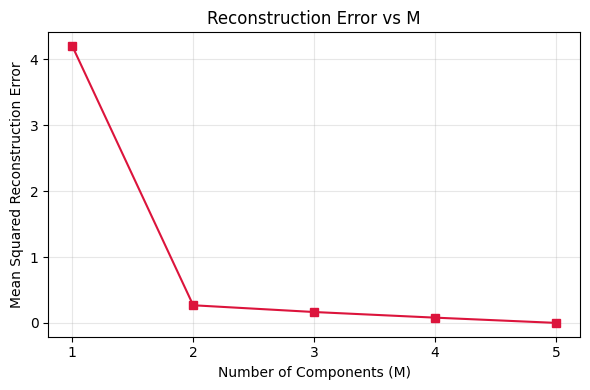

In [7]:
# ── Reconstruction error vs number of components ──
errors = []
for m in range(1, D + 1):
    U_m = eigenvectors[:, :m]
    Z_m = X_centered @ U_m
    X_rec_m = Z_m @ U_m.T
    mse = np.mean(np.sum((X_centered - X_rec_m) ** 2, axis=1))
    errors.append(mse)

plt.figure(figsize=(6, 4))
plt.plot(range(1, D + 1), errors, "s-", color="crimson")
plt.xlabel("Number of Components (M)")
plt.ylabel("Mean Squared Reconstruction Error")
plt.title("Reconstruction Error vs M")
plt.xticks(range(1, D + 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Image shape: 2878 × 4317 × 3  (37,272,978 values)


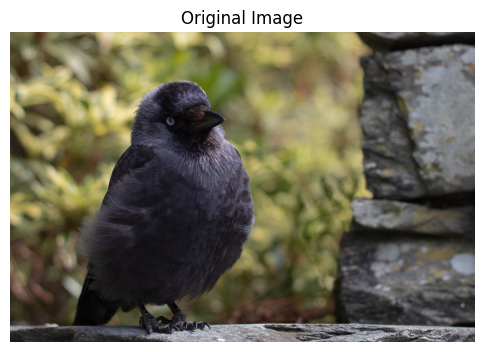

In [8]:
# ── PCA Image Compression Demo (bird.jpg) ──
from PIL import Image

img = Image.open("bird.jpg")
img_array = np.array(img, dtype=np.float64) / 255.0   # normalise to [0, 1]
H, W, C = img_array.shape

print(f"Image shape: {H} × {W} × {C}  ({H*W*C:,} values)")
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_array)
ax.set_title("Original Image")
ax.axis("off")
plt.show()

In [9]:
def pca_compress_channel(channel, n_components):
    """Apply PCA on a single (H, W) channel matrix and reconstruct it."""
    mean = channel.mean(axis=0)
    centered = channel - mean
    # Covariance matrix (W × W)
    cov = (centered.T @ centered) / channel.shape[0]
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    # Sort descending
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    # Keep top-k
    U_k = eigenvectors[:, :n_components]        # (W, k)
    Z   = centered @ U_k                         # (H, k)  — compressed
    reconstructed = Z @ U_k.T + mean             # (H, W)  — reconstructed
    return np.clip(reconstructed, 0, 1), eigenvalues

def pca_compress_image(image, n_components):
    """Compress an RGB image by applying PCA independently to each channel."""
    channels = []
    for c in range(3):
        rec, _ = pca_compress_channel(image[:, :, c], n_components)
        channels.append(rec)
    return np.stack(channels, axis=2)

print("PCA compression functions defined.")

PCA compression functions defined.


In [10]:
# ── Reconstruct with different component counts ──
component_list = [5, 20, 50, 100, 200]

compressed_images = {}
for k in component_list:
    compressed_images[k] = pca_compress_image(img_array, k)
    print(f"k = {k:>3d}  done")

k =   5  done
k =  20  done
k =  50  done
k = 100  done
k = 200  done


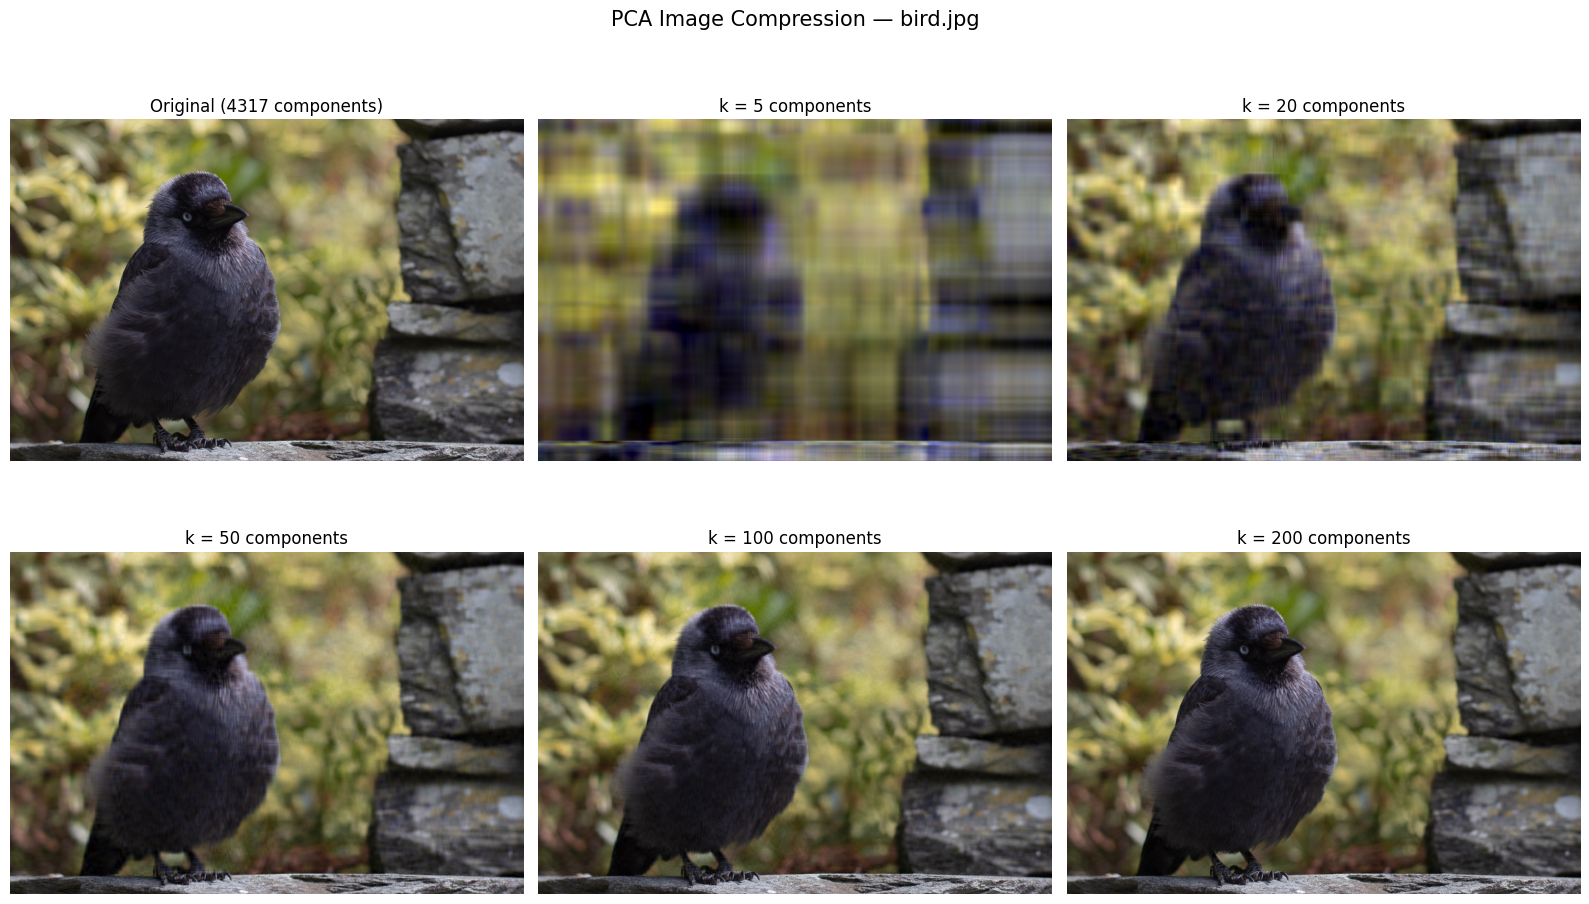

In [11]:
# ── Visual comparison ──
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

axes[0].imshow(img_array)
axes[0].set_title(f"Original ({W} components)")
axes[0].axis("off")

for i, k in enumerate(component_list):
    axes[i + 1].imshow(compressed_images[k])
    axes[i + 1].set_title(f"k = {k} components")
    axes[i + 1].axis("off")

plt.suptitle("PCA Image Compression — bird.jpg", fontsize=15)
plt.tight_layout()
plt.show()

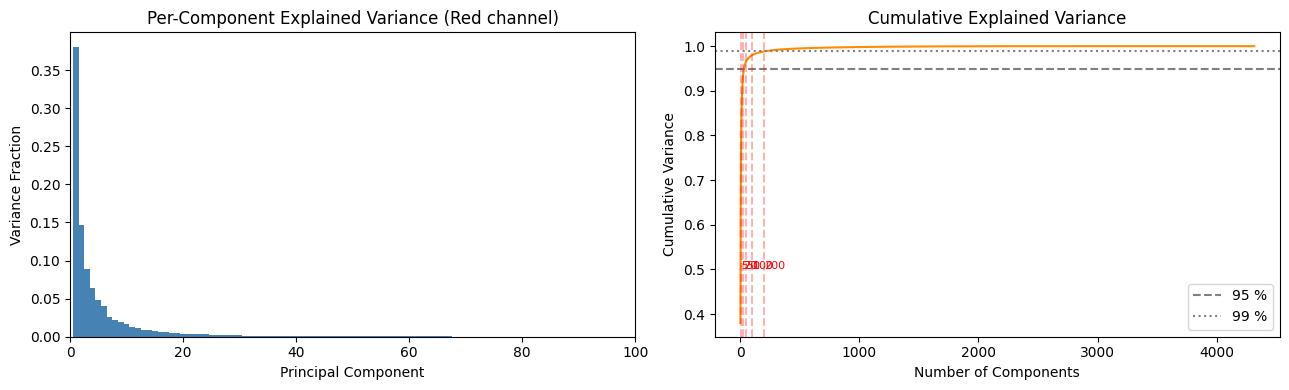

In [12]:
# ── Explained variance curve (Red channel) ──
_, eigenvalues_r = pca_compress_channel(img_array[:, :, 0], W)
explained = eigenvalues_r / eigenvalues_r.sum()
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(explained) + 1), explained, color="steelblue", width=1)
axes[0].set_xlim(0, 100)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Variance Fraction")
axes[0].set_title("Per-Component Explained Variance (Red channel)")

axes[1].plot(range(1, len(cumulative) + 1), cumulative, color="darkorange")
axes[1].axhline(0.95, ls="--", color="gray", label="95 %")
axes[1].axhline(0.99, ls=":",  color="gray", label="99 %")
for k in component_list:
    axes[1].axvline(k, ls="--", alpha=0.3, color="red")
    axes[1].text(k + 1, 0.5, str(k), fontsize=8, color="red")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# ── Compression ratio & quality metrics ──
original_size = H * W * 3   # total float values in original image

print(f"{'k':>5} {'Compression':>13} {'MSE':>10} {'PSNR (dB)':>10}")
print("-" * 42)

for k in component_list:
    rec = compressed_images[k]
    # Compressed storage per channel:
    #   k means + k×W eigenvector entries + H×k projection scores
    compressed_size = 3 * (k * (1 + W) + H * k)
    ratio = original_size / compressed_size

    mse  = np.mean((img_array - rec) ** 2)
    psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float("inf")

    print(f"{k:>5d} {ratio:>12.2f}x {mse:>10.6f} {psnr:>9.2f}")

    k   Compression        MSE  PSNR (dB)
------------------------------------------
    5       345.31x   0.008884     20.51
   20        86.33x   0.002637     25.79
   50        34.53x   0.001211     29.17
  100        17.27x   0.000721     31.42
  200         8.63x   0.000418     33.79
